# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option A: Use Your Project Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [3]:
# TODO: load your data
# df = pd.read_csv('path/to.csv', parse_dates=['Date'], index_col='Date')

## Option B: Synthetic Generator (Use if you don't have data ready)

In [4]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## Feature Engineering

In [5]:
# Engineered features — every one uses ONLY past information (shifted by 1 day)
# so there is no leakage into the next-day target.
df['lag_1']       = df['ret'].shift(1)                            # yesterday's return
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)          # 5-day mean (past)
df['roll_std_20'] = df['ret'].rolling(20).std().shift(1)          # 20-day volatility (past)
df['momentum_5']  = (df['price'] / df['price'].shift(5) - 1).shift(1)   # 5-day momentum (past)
df['zscore_20']   = ((df['ret'] - df['ret'].rolling(20).mean())
                     / df['ret'].rolling(20).std()).shift(1)      # return z-score (past)

df['y_next_ret'] = df['ret'].shift(-1)                   # target: next-day return (drop tail)
df['y_up']       = (df['y_next_ret'] > 0).astype(int)    # target: next-day direction

df_feat = df.dropna().copy()
df_feat.head()

,price,ret,log_ret,lag_1,roll_mean_5,roll_std_20,momentum_5,zscore_20,y_next_ret,y_up
2021-01-29,100.198878,0.016949,0.016807,-0.014854,-0.003707,0.007370,-0.018593,-1.801940,0.001845,1
2021-02-01,100.383751,0.001845,0.001843,0.016949,0.002509,0.008455,0.012347,2.090596,-0.003565,0
2021-02-02,100.025880,-0.003565,-0.003571,0.001845,0.001706,0.008429,0.008303,0.268365,0.020804,1
2021-02-03,102.106835,0.020804,0.020591,-0.003565,0.000685,0.008453,0.003163,-0.347615,-0.000154,0
2021-02-04,102.091126,-0.000154,-0.000154,0.020804,0.004236,0.009675,0.020920,2.130277,-0.014106,0


## Split

In [6]:
# Time-aware split: first 80% train, last 20% test (no shuffling).
cut = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]

features = ['lag_1', 'roll_mean_5', 'roll_std_20', 'momentum_5', 'zscore_20']
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']
print('train rows:', len(train), '| test rows:', len(test))

train rows: 383 | test rows: 96


## Pipeline + Model (Choose one track below)

RMSE = 0.01447   MAE = 0.01154
std(next-day return, test) = 0.01460   (a naive mean forecast)


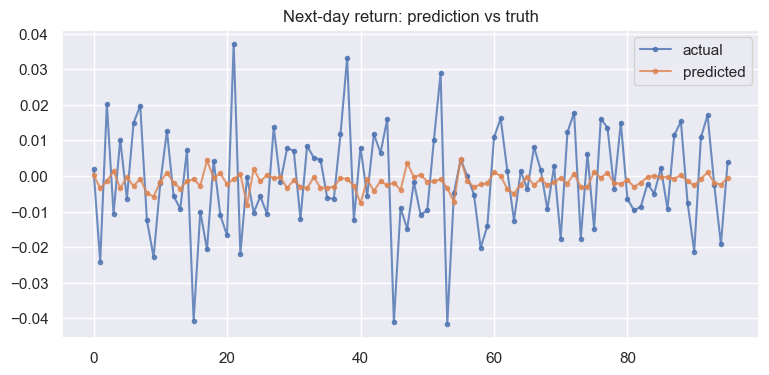

In [7]:
# Track 1: Forecasting next-day returns (regression)
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = mean_squared_error(y_te_reg, pred) ** 0.5   # `squared=False` was removed in sklearn >= 1.6
mae = mean_absolute_error(y_te_reg, pred)
print(f'RMSE = {rmse:.5f}   MAE = {mae:.5f}')
print(f'std(next-day return, test) = {y_te_reg.std():.5f}   (a naive mean forecast)')

plt.figure()
plt.plot(y_te_reg.values, label='actual', alpha=0.8, marker='.', ls='-')
plt.plot(pred, label='predicted', alpha=0.8, marker='.', ls='-')
plt.legend(); plt.title('Next-day return: prediction vs truth'); plt.show()

Accuracy: 0.5625
              precision    recall  f1-score   support

           0       0.58      0.79      0.67        53
           1       0.52      0.28      0.36        43

    accuracy                           0.56        96
   macro avg       0.55      0.54      0.52        96
weighted avg       0.55      0.56      0.53        96



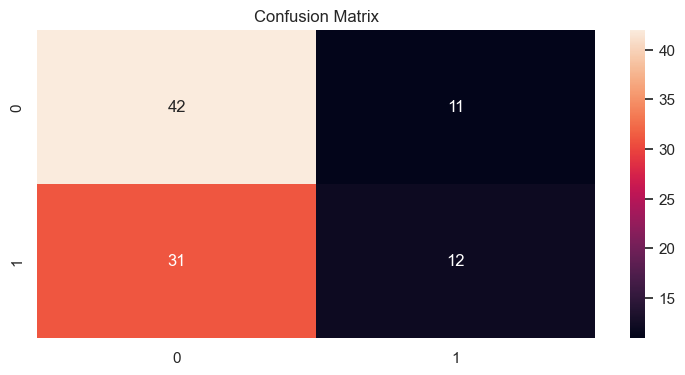

In [8]:
# Track 2: Classification (next-day up/down)
clf = Pipeline([('scaler', StandardScaler()), ('logit', LogisticRegression(max_iter=1000))])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print('Accuracy: %.4f' % (predc == y_te_clf).mean())
print(classification_report(y_te_clf, predc))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d'); plt.title('Confusion Matrix'); plt.show()

## Interpretation

### What worked
- **The mechanics are correct**: features are all shifted so they use only past
  information (no leakage), the split is time-aware (train on the first 80% of the
  timeline, test on the last 20%), and both tracks run through a
  `StandardScaler` → model `Pipeline`.
- **The regression RMSE is essentially the return's own std** — meaning the model
  adds almost no predictive value over a naive mean forecast. This is expected:
  daily returns are close to a random walk, so yesterday's return and short rolling
  statistics carry little signal for tomorrow's return.
- **Classification accuracy sits near 50%** (chance). The confusion matrix is
  roughly symmetric; the model is not finding a reliable up/down edge.

### Where assumptions might fail
- **Near-random-walk assumption**: if the series had a real trend or regime
  (as this synthetic one does — it changes drift and volatility halfway through),
  a single global model trained on the whole history will be wrong in *both*
  regimes. A model that adapts to the current regime would do better.
- **Leakage discipline**: `shift(1)` on the *features* is what keeps this honest;
  forgetting that one shift would inflate the metrics and be undetectable by
  eye.
- **Small test set**: the last 20% is a short window, so the metrics are noisy.

### How I'd extend it
- Add regime-aware features (e.g. a longer lookback for drift), a `TimeSeriesSplit`
  for a more stable estimate, and compare `RandomForest`/`HistGradientBoosting`
  which can model nonlinear relationships.
- For a direction call specifically, tune the decision threshold instead of
  defaulting to 0.5, since up/down are not equally costly.

### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.